In [13]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [28]:
df = pd.read_pickle('../../data/processed/filtered_out_articles.pkl')

In [30]:
df['is_near_duplicate_90'] = (
    df['is_near_duplicate_90']
    .fillna(False)
    .astype(bool)
)


In [31]:
df = df.loc[df['is_near_duplicate_90']]

In [32]:
df.shape

(1154, 13)

In [33]:
df.head()

,title,publisher_raw,date,section,length,body,correction_appended,load_date_at_end,source_file,title_stand,publisher,is_near_duplicate_90,duplicate_of_index_90
0,Trump's Re-election Defines a New Era of Ameri...,The New York Times,2024-12-27,Section A; Column 0; National Desk; Pg. 13,1697,The Obama-Romney race in 2012 was the last in ...,False,False,NYT/1.DOCX,trumps reelection defines a new era of america...,New York Times,True,5135.0
1,What Ever Happened to the Lady Jaguars?,The New York Times,2024-12-15,Section F; Column 0; SpecialSections; Pg. 2,4967,Her name is Hannah. When I met her more than a...,False,False,NYT/2.DOCX,what ever happened to the lady jaguars,New York Times,True,39350.0
2,When a Baby Killer Isn't a Straightforward Vil...,The New York Times,2024-12-07,Section C; Column 0; The Arts/Cultural Desk; P...,886,The real-life murderer who inspired ''The Girl...,False,False,NYT/1.DOCX,when a baby killer isnt a straightforward villain,New York Times,True,18524.0
4,"As French Rape Trial Nears End, Wife Speaks of...",The New York Times,2024-11-20,Section A; Column 0; Foreign Desk; Pg. 11,967,Gisèle Pelicot made her final address to the c...,False,False,NYT/1.DOCX,as french rape trial nears end wife speaks of ...,New York Times,True,26521.0
10,"Tiny Homes Face the Ax in Hong Kong, Leaving M...",The New York Times,2024-11-05,WORLD; asia,1364,The government says the city's smallest apartm...,False,False,NYT/2.DOCX,tiny homes face the ax in hong kong leaving ma...,New York Times,True,19899.0


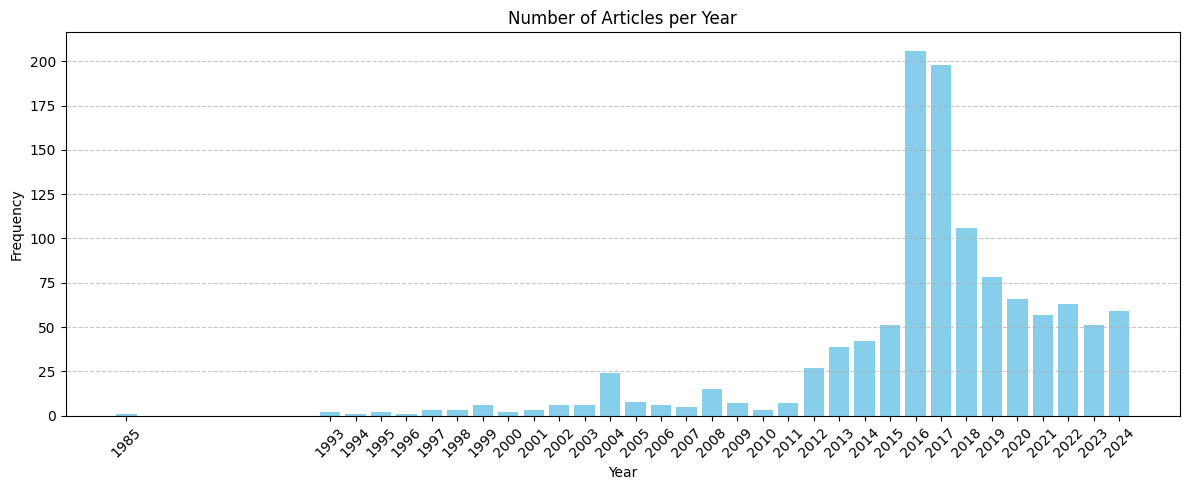

In [34]:
# parse dates
parsed_dates = pd.to_datetime(df["date"], errors="coerce").dt.date
# Group by year
years = [d.year for d in parsed_dates]
year_counts = Counter(years)

# Sort by year
sorted_years = sorted(year_counts)
frequencies = [year_counts[year] for year in sorted_years]

# Plot
plt.figure(figsize=(12, 5))
plt.bar(sorted_years, frequencies, color='skyblue')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Number of Articles per Year')
plt.xticks(sorted_years, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

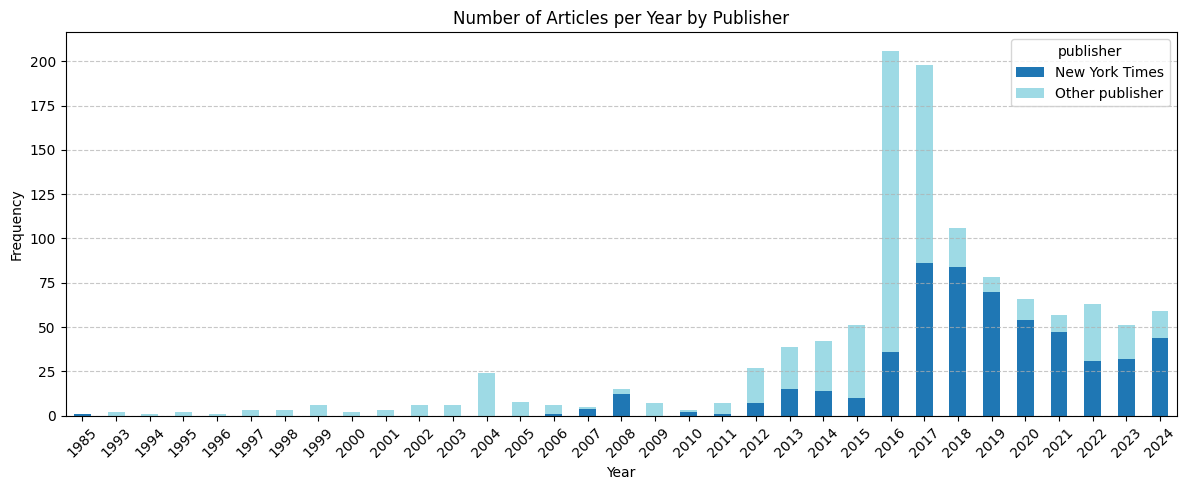

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Parse dates safely
df["parsed_date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["parsed_date"].dt.year

# Group by year + publisher
year_pub_counts = df.groupby(["year", "publisher"]).size().unstack(fill_value=0)

# Plot stacked bar chart
#plt.figure(figsize=(12, 5))
year_pub_counts.plot(
    kind="bar", stacked=True, figsize=(12, 5), colormap="tab20"
)

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Number of Articles per Year by Publisher")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [40]:
df_full = pd.read_pickle('../../data/processed/cleaned_articles.pkl')
df = pd.read_pickle('../../data/processed/filtered_out_articles.pkl')
df_full = pd.concat([df_full, df])
df_full.shape

(43666, 17)

In [42]:
df_full['is_near_duplicate_90'] = (
    df_full['is_near_duplicate_90']
    .fillna(False)
    .astype(bool)
)


In [43]:
df_full

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,correction_appended,load_date_at_end,title_stand,is_near_duplicate_90,duplicate_of_index_90
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Egypt, Mexico, Nicaragua, Canada]","[Rhode Island, Washington, Massachusetts, US]",NYT/1.DOCX,The New York Times,NaN,NaN,NaN,False,NaN
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Sierra Leone, United Kingdom, Japan]","[Washington, Florida, Ohio, Oregon, USA, Massa...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),NaN,NaN,NaN,False,NaN
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,US_ONLY,[],"[New York, United States, US, North Carolina]",NYT/1.DOCX,The New York Times,NaN,NaN,NaN,False,NaN
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,[Brazil],"[New York, United States, US]",NYT/1.DOCX,The New York Times,NaN,NaN,NaN,False,NaN
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[Maryland, Pennsylvania, Ohio, West Virginia, ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,NaN,NaN,NaN,False,NaN


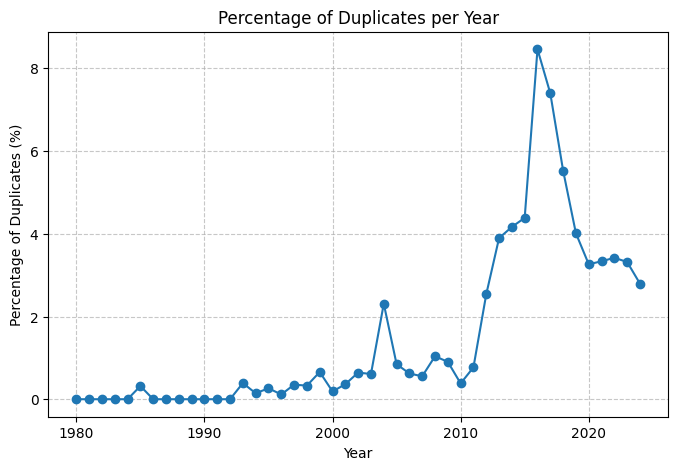

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_full['date'] = pd.to_datetime(df_full['date'])

# Extract year
df_full['year'] = df_full['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats = df_full.groupby('year')['is_near_duplicate_90'].mean() * 100

# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats.index, dup_stats.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [45]:
dup_stats

year
1980    0.000000
1981    0.000000
1982    0.000000
1983    0.000000
1984    0.000000
1985    0.318471
1986    0.000000
1987    0.000000
1988    0.000000
1989    0.000000
1990    0.000000
1991    0.000000
1992    0.000000
1993    0.390625
1994    0.143885
1995    0.264201
1996    0.114548
1997    0.352941
1998    0.328228
1999    0.658617
2000    0.187266
2001    0.363196
2002    0.645161
2003    0.609137
2004    2.309913
2005    0.847458
2006    0.622407
2007    0.554324
2008    1.038781
2009    0.904393
2010    0.381679
2011    0.770925
2012    2.537594
2013    3.896104
2014    4.166667
2015    4.385211
2016    8.463435
2017    7.396339
2018    5.529473
2019    4.012346
2020    3.264095
2021    3.335284
2022    3.420195
2023    3.318152
2024    2.794884
Name: is_near_duplicate_90, dtype: float64